<a href="https://colab.research.google.com/github/kesavraov-2005/Lenskart-Data-Analysis/blob/main/lenskart.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

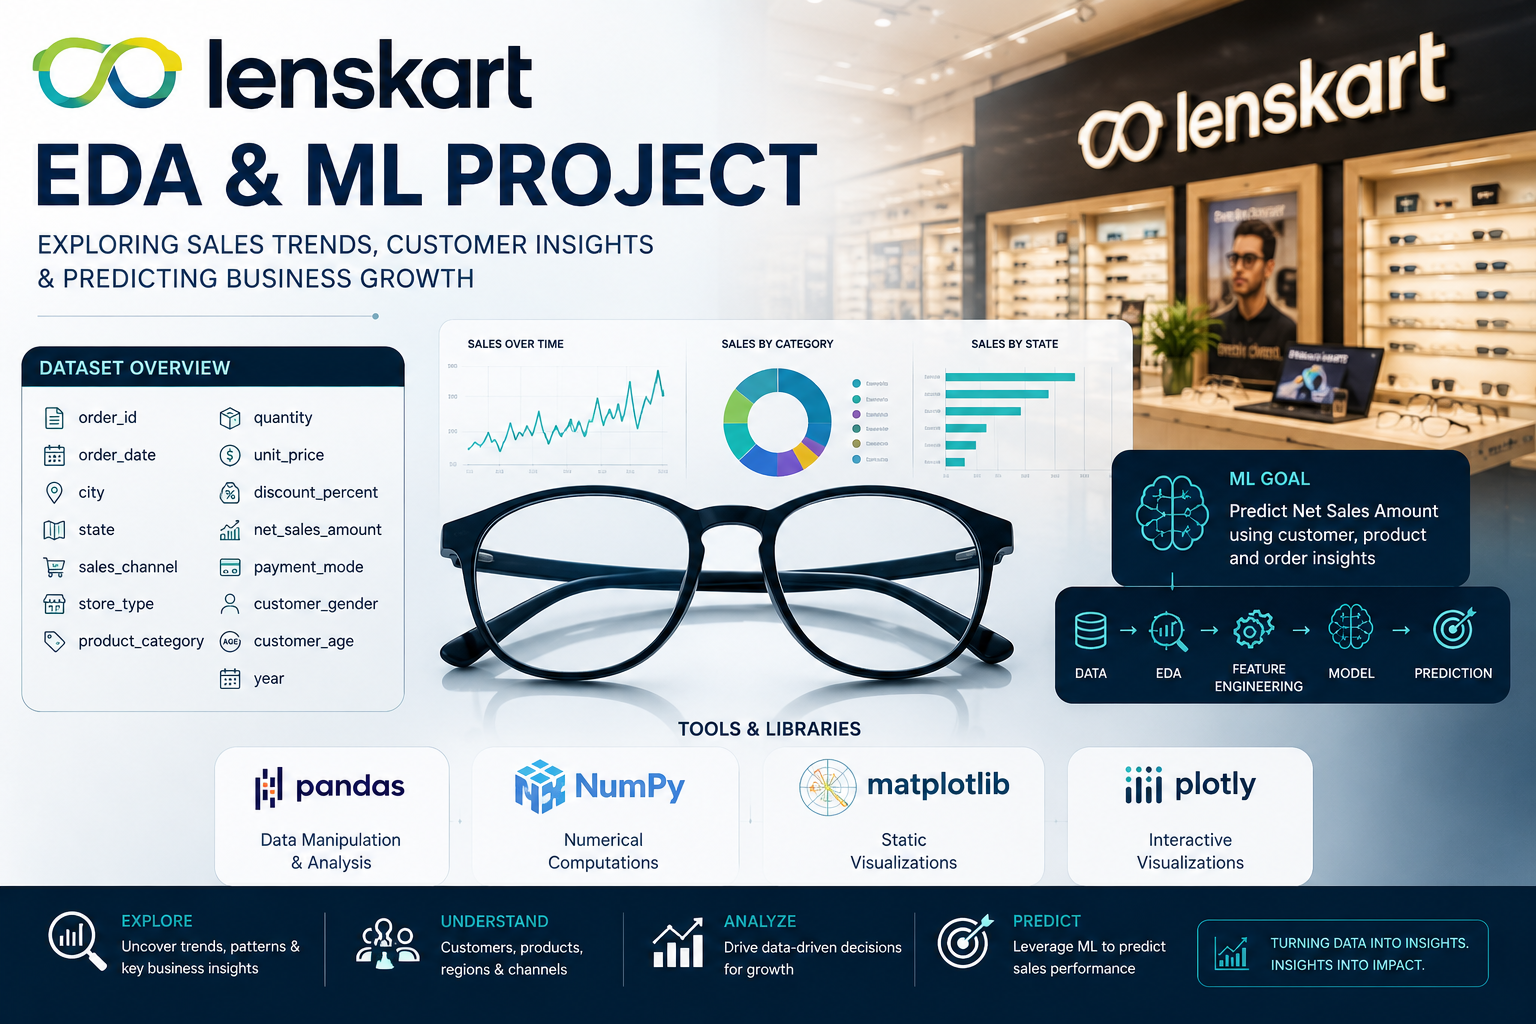

In [ ]:
#preprocessing step while importing data to clean and visualize

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objs as go

In [ ]:
a=pd.read_csv("/content/Lenskart India.csv")


In [ ]:
df=pd.read_csv("/content/Lenskart India.csv")
df

,order_id,order_date,city,state,sales_channel,store_type,product_category,quantity,unit_price,discount_percent,net_sales_amount,payment_mode,customer_gender,customer_age,year
0,ORD1000000,17-05-2023,Bhopal,Madhya Pradesh,Online,Online Only,Sunglasses,3,1659,0,4977.0,Net Banking,Female,25,2023
1,ORD1000001,24-04-2022,Faridabad,Haryana,Online,Online Only,Computer Glasses,1,3891,0,3891.0,Credit Card,Female,36,2022
2,ORD1000002,05-06-2022,Kolkata,West Bengal,Offline,Standalone Store,Contact Lenses,3,4243,10,11456.1,Debit Card,Female,41,2022
3,ORD1000003,24-03-2024,Ahmedabad,Gujarat,Offline,Online Only,Sunglasses,3,2484,0,7452.0,Credit Card,Female,41,2024
4,ORD1000004,17-08-2024,Ahmedabad,Gujarat,Online,Online Only,Contact Lenses,2,3232,0,6464.0,Debit Card,Other,38,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,ORD1149995,18-05-2024,Bengaluru,Karnataka,Online,Online Only,Contact Lenses,2,2617,25,3925.5,Debit Card,Female,26,2024
149996,ORD1149996,12-07-2023,Chennai,Tamil Nadu,Offline,High Street Store,Eyeglasses,2,2586,10,4654.8,Credit Card,Female,49,2023
149997,ORD1149997,23-04-2023,Cuttack,Odisha,Offline,Online Only,Eyeglasses,1,4793,20,3834.4,Net Banking,Male,35,2023
149998,ORD1149998,24-04-2023,Trivandrum,Kerala,Online,Online Only,Sunglasses,2,967,0,1934.0,Net Banking,Other,32,2023


In [ ]:
df["age_group"]=""
df.loc[df["customer_age"]>18,"age_group"]="children"
df.loc[(df["customer_age"]>=18) & (df["customer_age"]<39),"age_group"]="young_adult"
df.loc[(df["customer_age"]>=40) & (df["customer_age"]<60),"age_group"]="middle_age_adult"
df.loc[df["customer_age"]>=60,"age_group"]="senior citizen"

In [ ]:
df

,order_id,order_date,city,state,sales_channel,store_type,product_category,quantity,unit_price,discount_percent,net_sales_amount,payment_mode,customer_gender,customer_age,year
0,ORD1000000,17-05-2023,Bhopal,Madhya Pradesh,Online,Online Only,Sunglasses,3,1659,0,4977.0,Net Banking,Female,25,2023
1,ORD1000001,24-04-2022,Faridabad,Haryana,Online,Online Only,Computer Glasses,1,3891,0,3891.0,Credit Card,Female,36,2022
2,ORD1000002,05-06-2022,Kolkata,West Bengal,Offline,Standalone Store,Contact Lenses,3,4243,10,11456.1,Debit Card,Female,41,2022
3,ORD1000003,24-03-2024,Ahmedabad,Gujarat,Offline,Online Only,Sunglasses,3,2484,0,7452.0,Credit Card,Female,41,2024
4,ORD1000004,17-08-2024,Ahmedabad,Gujarat,Online,Online Only,Contact Lenses,2,3232,0,6464.0,Debit Card,Other,38,2024
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,ORD1149995,18-05-2024,Bengaluru,Karnataka,Online,Online Only,Contact Lenses,2,2617,25,3925.5,Debit Card,Female,26,2024
149996,ORD1149996,12-07-2023,Chennai,Tamil Nadu,Offline,High Street Store,Eyeglasses,2,2586,10,4654.8,Credit Card,Female,49,2023
149997,ORD1149997,23-04-2023,Cuttack,Odisha,Offline,Online Only,Eyeglasses,1,4793,20,3834.4,Net Banking,Male,35,2023
149998,ORD1149998,24-04-2023,Trivandrum,Kerala,Online,Online Only,Sunglasses,2,967,0,1934.0,Net Banking,Other,32,2023


In [ ]:
# Age group analysis in product_category

a=df[df["product_category"]=="Eyeglasses"]["age_group"].value_counts()
b=df[df["product_category"]=="Contact Lenses"]["age_group"].value_counts()
c=df[df['product_category']=="Sunglasses"]["age_group"].value_counts()
d=df[df["product_category"]=="Computer Glasses"]["age_group"].value_counts()
print(f"Eyeglasses: {a}")
print("------")
print(f"Contact Lenses: {b}")
print("------")
print(f"Sunglasses: {c}")
print("------")
print(f"Computer Glasses: {d}")


Eyeglasses: age_group
young_adult         16736
middle_age_adult    16042
senior citizen       4110
children              829
Name: count, dtype: int64
------
Contact Lenses: age_group
young_adult         16702
middle_age_adult    15918
senior citizen       4028
children              824
Name: count, dtype: int64
------
Sunglasses: age_group
young_adult         16543
middle_age_adult    16083
senior citizen       3979
children              800
Name: count, dtype: int64
------
Computer Glasses: age_group
young_adult         16637
middle_age_adult    15981
senior citizen       3997
children              791
Name: count, dtype: int64


In [ ]:
fig=px.bar(x=a.index, y=a.values)
fig2=px.bar(x=b.index, y=b.values)
fig3=px.bar(x=c.index, y=c.values)
fig4=px.bar(x=d.index, y=d.values)

sub_fig=make_subplots(rows=2,cols=2,subplot_titles=("Eyeglasses","Contact Lenses","Sunglasses","Computer Glasses"))

for i in fig.data:
  sub_fig.add_trace(i,row=1,col=1)

for i in fig2.data:
  sub_fig.add_trace(i,row=1,col=2)

for i in fig3.data:
  sub_fig.add_trace(i,row=2,col=1)

for i in fig4.data:
  sub_fig.add_trace(i,row=2,col=2)

sub_fig.update_layout(title="Age Group Comparison",showlegend=False,height=500,width=1000)
sub_fig.show()

In [ ]:
df.drop("order_id",axis=1,inplace=True)
df.drop("order_date",axis=1,inplace=True)

In [ ]:
#HeatMap to check best fit for target value

import plotly.express as px
corr_matrix=df.corr()
fig=px.imshow(corr_matrix,text_auto=True,color_continuous_scale="blues",height=1500,width=1000)
fig.show()

In [ ]:
#state wise analsysis in sales

fig = px.histogram(df, x="state")
fig.show()

In [ ]:
b=a[a["state"]=="Kerala"]["product_category"].value_counts()
b

,count
product_category,
Eyeglasses,3326
Contact Lenses,3316
Computer Glasses,3297
Sunglasses,3255


In [ ]:
#payment mode analysis using pie chart

fig=px.pie(df,names="payment_mode",values="net_sales_amount")
fig.show()

In [ ]:
df["net banking"]=""
df.loc[df["payment_mode"]=="Net Banking","net banking"]="Net Banking"

In [ ]:
df.groupby("age_group")["net banking"].count()

,net banking
age_group,
0,3244
1,64024
2,16114
3,66618


In [22]:
#Machine Learning algorithum

from sklearn.ensemble import RandomForestRegressor
#from sklearn.tree import DecisionTreeRegressor
#from sklearn.linear_model import LinearRegression
#from sklearn.naive_bayes import GaussianNB
#from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,r2_score,mean_squared_error
#from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
df.columns

Index(['order_id', 'order_date', 'city', 'state', 'sales_channel',
       'store_type', 'product_category', 'quantity', 'unit_price',
       'discount_percent', 'net_sales_amount', 'payment_mode',
       'customer_gender', 'customer_age', 'year', 'age_group', 'net banking'],
      dtype='object')

In [ ]:
le=LabelEncoder()
df["city"]=le.fit_transform(df["city"])
df["state"]=le.fit_transform(df["state"])
df["sales_channel"]=le.fit_transform(df["sales_channel"])
df["store_type"]=le.fit_transform(df["store_type"])
df["product_category"]=le.fit_transform(df["product_category"])
df["customer_gender"]=le.fit_transform(df["customer_gender"])
df["payment_mode"]=le.fit_transform(df["payment_mode"])
df["age_group"]=le.fit_transform(df["age_group"])
df["net banking"]=le.fit_transform(df["net banking"])

In [ ]:
df

,order_id,order_date,city,state,sales_channel,store_type,product_category,quantity,unit_price,discount_percent,net_sales_amount,payment_mode,customer_gender,customer_age,year,age_group,net banking
0,ORD1000000,17-05-2023,2,8,1,2,3,3,1659,0,4977.0,3,0,25,2023,3,0
1,ORD1000001,24-04-2022,9,4,1,2,0,1,3891,0,3891.0,1,0,36,2022,3,0
2,ORD1000002,05-06-2022,15,15,0,3,1,3,4243,10,11456.1,2,0,41,2022,1,0
3,ORD1000003,24-03-2024,0,3,0,2,3,3,2484,0,7452.0,1,0,41,2024,1,0
4,ORD1000004,17-08-2024,0,3,1,2,1,2,3232,0,6464.0,2,2,38,2024,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149995,ORD1149995,18-05-2024,1,6,1,2,1,2,2617,25,3925.5,2,0,26,2024,3,0
149996,ORD1149996,12-07-2023,5,12,0,0,2,2,2586,10,4654.8,1,0,49,2023,1,0
149997,ORD1149997,23-04-2023,7,10,0,2,2,1,4793,20,3834.4,3,1,35,2023,3,0
149998,ORD1149998,24-04-2023,22,7,1,2,3,2,967,0,1934.0,3,2,32,2023,3,0


In [ ]:
x=df.drop(["net_sales_amount","order_id", "order_date"],axis=1)
y=df["net_sales_amount"]

In [ ]:
#train & test the data

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [20]:
model=RandomForestRegressor()
model.fit(x_train,y_train)

RandomForestRegressor()

In [25]:
y_pred=model.predict(x_test)
print("Mean Absolute Error:",mean_absolute_error(y_test,y_pred))
print("R2 Score:",r2_score(y_test,y_pred))
print("Mean Squared Error:",mean_squared_error(y_test,y_pred))

Mean Absolute Error: 0.7550927833334283
R2 Score: 0.9999998532633639
Mean Squared Error: 1.5281417978417142
